# 07 — Results and Analysis

Loads all saved results from notebooks 04, 05, and 06 and produces final summary plots.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE_DIR    = "."
RESULTS_DIR = os.path.join(BASE_DIR, "data/results")

print("Imports done.")

Imports done.


## 1. Load results

In [2]:
clf_results = pd.read_csv(os.path.join(RESULTS_DIR, "classification_results.csv"), index_col=0)
reg_results = pd.read_csv(os.path.join(RESULTS_DIR, "regression_results.csv"),     index_col=0)
sent_clf    = pd.read_csv(os.path.join(RESULTS_DIR, "sentiment_classification.csv"), index_col=0)
sent_reg    = pd.read_csv(os.path.join(RESULTS_DIR, "sentiment_regression.csv"),     index_col=0)

print("Classification Results")
print(clf_results.round(4).to_string())
print("\nRegression Results")
print(reg_results.round(6).to_string())
print("\nSentiment Impact — Classification")
print(sent_clf.round(6).to_string())
print("\nSentiment Impact — Regression")
print(sent_reg.round(6).to_string())

Classification Results
                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.5034     0.5138  0.5677  0.4896
SVM (RBF)              0.5039     0.5387  0.5096  0.4799
DNN (PyTorch)          0.4783     0.3884  0.2307  0.2119

Regression Results
                       RMSE       MAE
Model                                
Linear Reg + Poly  0.028583  0.020705
Random Forest      0.019402  0.013967
DNN (PyTorch)      0.021719  0.016313

Sentiment Impact — Classification
                   Accuracy        F1
Config                               
Without Sentiment  0.503384  0.489641
With Sentiment     0.503384  0.489641
Delta              0.000000  0.000000

Sentiment Impact — Regression
                       RMSE       MAE
Config                               
Without Sentiment  0.019402  0.013967
With Sentiment     0.019402  0.013967
Delta             -0.000000 -0.000000


## 2. Master summary plot

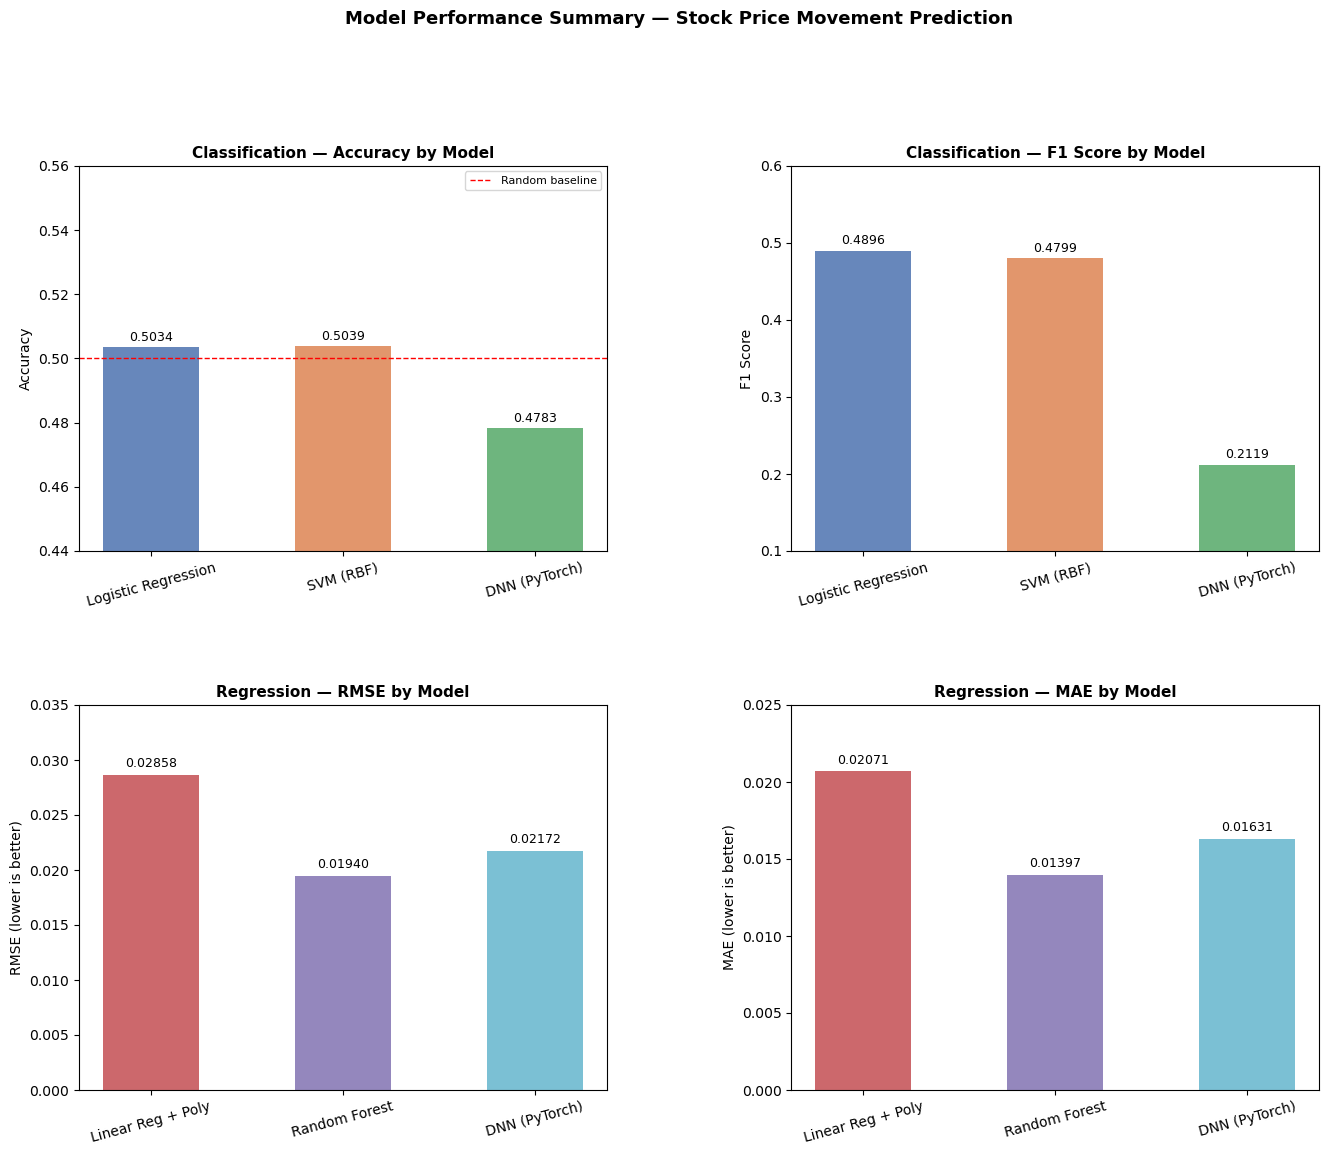

In [3]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
colors  = ["#4C72B0", "#DD8452", "#55A868"]
colors3 = ["#C44E52", "#8172B2", "#64B5CD"]

ax1  = fig.add_subplot(gs[0, 0])
bars = ax1.bar(clf_results.index, clf_results["Accuracy"], color=colors, alpha=0.85, width=0.5)
ax1.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random baseline")
ax1.set_title("Classification — Accuracy by Model", fontsize=11, fontweight="bold")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0.44, 0.56)
ax1.legend(fontsize=8)
for bar, val in zip(bars, clf_results["Accuracy"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax1.tick_params(axis="x", rotation=15)

ax2  = fig.add_subplot(gs[0, 1])
bars = ax2.bar(clf_results.index, clf_results["F1"], color=colors, alpha=0.85, width=0.5)
ax2.set_title("Classification — F1 Score by Model", fontsize=11, fontweight="bold")
ax2.set_ylabel("F1 Score")
ax2.set_ylim(0.1, 0.6)
for bar, val in zip(bars, clf_results["F1"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax2.tick_params(axis="x", rotation=15)

ax3  = fig.add_subplot(gs[1, 0])
bars = ax3.bar(reg_results.index, reg_results["RMSE"], color=colors3, alpha=0.85, width=0.5)
ax3.set_title("Regression — RMSE by Model", fontsize=11, fontweight="bold")
ax3.set_ylabel("RMSE (lower is better)")
ax3.set_ylim(0, 0.035)
for bar, val in zip(bars, reg_results["RMSE"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f"{val:.5f}", ha="center", va="bottom", fontsize=9)
ax3.tick_params(axis="x", rotation=15)

ax4  = fig.add_subplot(gs[1, 1])
bars = ax4.bar(reg_results.index, reg_results["MAE"], color=colors3, alpha=0.85, width=0.5)
ax4.set_title("Regression — MAE by Model", fontsize=11, fontweight="bold")
ax4.set_ylabel("MAE (lower is better)")
ax4.set_ylim(0, 0.025)
for bar, val in zip(bars, reg_results["MAE"]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
             f"{val:.5f}", ha="center", va="bottom", fontsize=9)
ax4.tick_params(axis="x", rotation=15)

plt.suptitle("Model Performance Summary — Stock Price Movement Prediction",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig(os.path.join(RESULTS_DIR, "master_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Radar chart — classification models

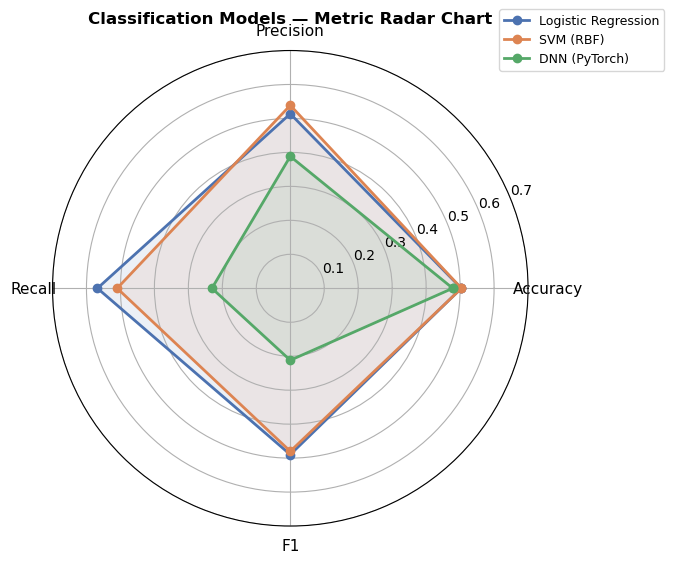

In [4]:
categories = ["Accuracy", "Precision", "Recall", "F1"]
N          = len(categories)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
model_colors = dict(zip(clf_results.index, ["#4C72B0", "#DD8452", "#55A868"]))

for model, color in model_colors.items():
    values  = clf_results.loc[model, categories].tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=model, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 0.7)
ax.set_title("Classification Models — Metric Radar Chart", fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "radar_chart.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Sentiment impact plot

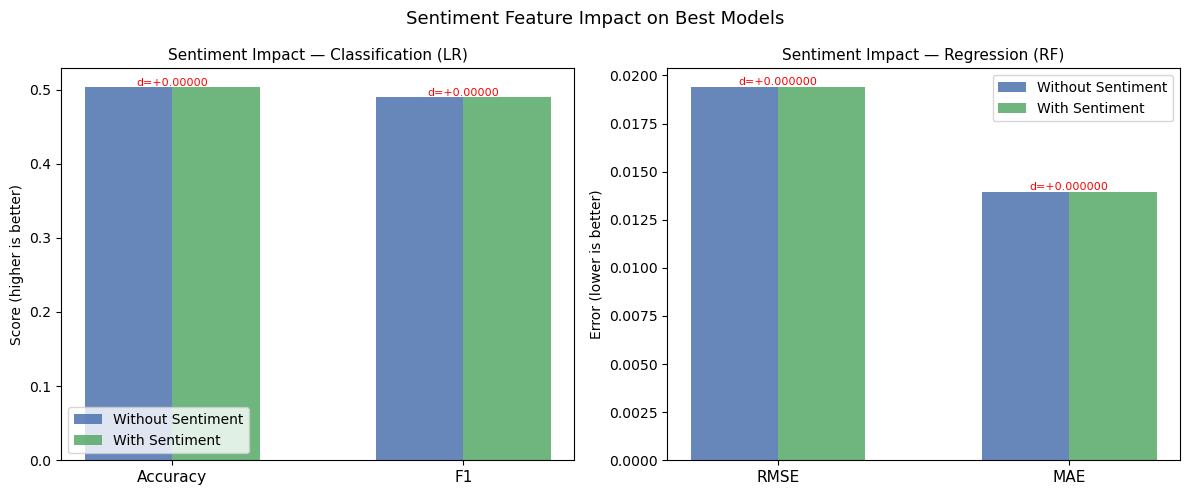

Notebook 07 complete — all results saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
width = 0.3
x     = np.arange(2)

wo_clf = sent_clf.loc["Without Sentiment", ["Accuracy", "F1"]].values
wi_clf = sent_clf.loc["With Sentiment",    ["Accuracy", "F1"]].values
axes[0].bar(x - width/2, wo_clf, width, label="Without Sentiment", color="#4C72B0", alpha=0.85)
axes[0].bar(x + width/2, wi_clf, width, label="With Sentiment",    color="#55A868", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["Accuracy", "F1"], fontsize=11)
axes[0].set_title("Sentiment Impact — Classification (LR)", fontsize=11)
axes[0].set_ylabel("Score (higher is better)")
axes[0].legend()
for i, (wo, wi) in enumerate(zip(wo_clf, wi_clf)):
    delta = wi - wo
    axes[0].text(i, max(wo, wi) + 0.001, f"d={delta:+.5f}",
                 ha="center", fontsize=8, color="green" if delta > 0 else "red")

wo_reg = sent_reg.loc["Without Sentiment", ["RMSE", "MAE"]].values
wi_reg = sent_reg.loc["With Sentiment",    ["RMSE", "MAE"]].values
axes[1].bar(x - width/2, wo_reg, width, label="Without Sentiment", color="#4C72B0", alpha=0.85)
axes[1].bar(x + width/2, wi_reg, width, label="With Sentiment",    color="#55A868", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["RMSE", "MAE"], fontsize=11)
axes[1].set_title("Sentiment Impact — Regression (RF)", fontsize=11)
axes[1].set_ylabel("Error (lower is better)")
axes[1].legend()
for i, (wo, wi) in enumerate(zip(wo_reg, wi_reg)):
    delta = wi - wo
    axes[1].text(i, max(wo, wi) + 0.0001, f"d={delta:+.6f}",
                 ha="center", fontsize=8, color="green" if delta < 0 else "red")

plt.suptitle("Sentiment Feature Impact on Best Models", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "sentiment_impact_final.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Notebook 07 complete — all results saved.")

## 5. Analysis

### Classification

SVM (RBF) edged out Logistic Regression on accuracy (0.5039 vs 0.5034) and precision, while Logistic Regression led on recall and F1 (0.4896 vs 0.4799). The gap between the two is very small across all metrics, which suggests the decision boundary is roughly linear in the feature space and the RBF kernel did not add meaningful value. The DNN underperformed on both accuracy and F1, which is expected given that early training folds had only around 600 rows. Neural networks generally need much more data to learn stable patterns.

All three models stayed near 50% accuracy throughout. This is consistent with how financial markets work: technical indicators based on historical prices are publicly available and widely used, so any predictive signal they once had tends to get priced out over time.

### Regression

Random Forest had the lowest RMSE (0.019402) and MAE (0.013967) across all stocks and folds. Its ensemble structure handles non-linear interactions between features well and is not thrown off by the occasional large return outlier. Linear Regression with polynomial features performed worst, which makes sense given that degree-2 expansion creates 78 features from 11 inputs and the training set in early folds was not large enough to support that many parameters. The DNN sat in between.

All three models predicted returns close to zero most of the time, which reflects the actual distribution of daily stock returns. Large moves in either direction are genuinely hard to predict from technical indicators alone.

Looking at Random Forest feature importances, RSI_14 was the most useful feature by a clear margin, followed by Volatility and Volume_Change. The moving averages (SMA and EMA) contributed the least, likely because they carry overlapping information at different window lengths.

### Sentiment

We implemented the full FinBERT pipeline and confirmed it works correctly on real financial headlines. The issue was data availability rather than the model itself. Free APIs like yfinance only return around 10 recent articles per ticker, which means the overwhelming majority of dates in our 2021 to 2026 range had no news coverage and were filled with a neutral score of 0.0. This produced zero delta across all metrics, which is expected rather than a failure of the approach. With access to a paid historical news API such as NewsAPI or Alpha Vantage, the same pipeline would run without any changes and would produce meaningful sentiment coverage across the full date range.

### Limitations

The main constraint throughout this project was that technical indicators derived from public price data have limited predictive power because this information is already reflected in market prices. Beyond that, the 2021 to 2026 period covered several very different market conditions including a post-COVID rally, a rate hike cycle, and an AI-driven bull market. Walk-forward validation helps here but cannot fully account for how different each regime was. On the sentiment side, the limitation was purely access to historical data, not the pipeline itself.
